In [7]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, csc_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

In [8]:
df_book_tags = pd.read_csv('archive2/book_tags.csv')
df_books = pd.read_csv('archive2/books.csv')
df_ratings = pd.read_csv('archive2/ratings.csv')
df_tags = pd.read_csv('archive2/tags.csv')
df_to_read = pd.read_csv('archive2/to_read.csv')

In [9]:
title_col = 'title' if 'title' in df_books.columns else 'original_title'
df_books["display_title"] = df_books[title_col].fillna("Unknown")

book_title_dict = df_books.set_index("id")["display_title"].to_dict()

for book_id in df_ratings["book_id"].unique():
    if book_id not in book_title_dict:
        book_title_dict[book_id] = "Unknown"

user_mean = df_ratings.groupby("user_id")["rating"].mean()
ratings = df_ratings.copy()
ratings["rating_centered"] = ratings["rating"] - ratings["user_id"].map(user_mean)

book_ids = ratings["book_id"].unique()
user_ids = ratings["user_id"].unique()

book_to_idx = {book: idx for idx, book in enumerate(book_ids)}
user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
idx_to_book = {idx: book for book, idx in book_to_idx.items()}

rows = ratings["book_id"].map(book_to_idx)
cols = ratings["user_id"].map(user_to_idx)
data = ratings["rating_centered"].astype(np.float32)

matrix_csr = csr_matrix(
    (data, (rows, cols)),
    shape=(len(book_ids), len(user_ids)),
    dtype=np.float32
)
matrix_csc = csc_matrix(matrix_csr, dtype=np.float32)

print(f"Матрица {matrix_csr.shape}, ненулевых: {matrix_csr.nnz}")

Матрица (10000, 53424), ненулевых: 979478


In [30]:
n_components = 8000
svd = TruncatedSVD(n_components=n_components, random_state=42)
book_embeddings = svd.fit_transform(matrix_csr)
user_embeddings = svd.components_.T

print(f"Объяснённая дисперсия: {svd.explained_variance_ratio_.sum():.4f}")

Объяснённая дисперсия: 0.9707


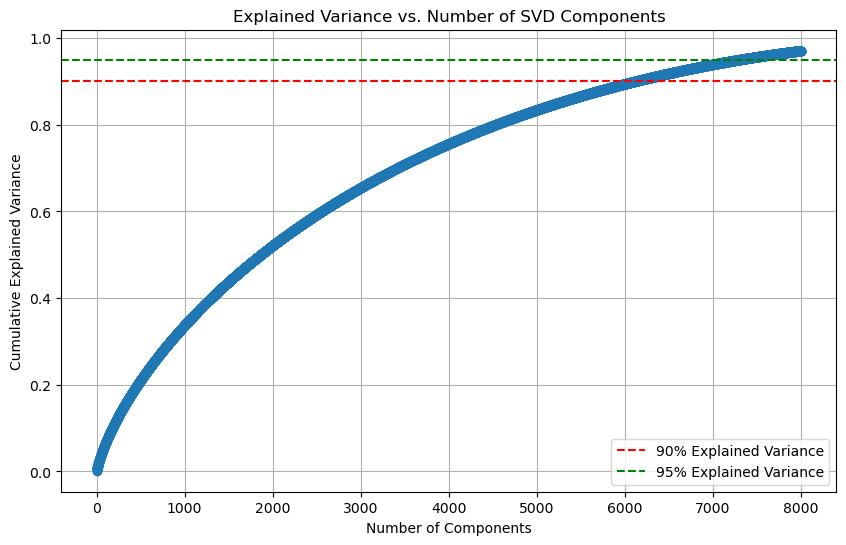

Для сохранения 90% дисперсии нужно 6113 компонент
Для сохранения 95% дисперсии нужно 7297 компонент


In [31]:
import matplotlib.pyplot as plt

cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Explained Variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% Explained Variance')
plt.legend()
plt.grid(True)
plt.title('Explained Variance vs. Number of SVD Components')
plt.show()

n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Для сохранения 90% дисперсии нужно {n_components_90} компонент")
print(f"Для сохранения 95% дисперсии нужно {n_components_95} компонент")

In [32]:
popular_books = (df_ratings.groupby("book_id").agg(avg_rating=("rating", "mean"),
                                                   rating_count=("rating", "count")).sort_values(["rating_count",
                                                                                                  "avg_rating"], ascending=False))

user_rated_books = (df_ratings.groupby("user_id")["book_id"].apply(set).to_dict())

In [33]:
def recommend_svd(user_id, matrix_csr, matrix_csc, book_embeddings, user_embeddings,
                  user_to_idx, idx_to_book, book_title_dict, popular_books, user_rated_books, user_mean, top_n=10):
    if user_id not in user_to_idx:
        top = popular_books.head(top_n).reset_index()
        top["title"] = top["book_id"].map(book_title_dict).fillna("Unknown")
        return top[["book_id", "title", "avg_rating", "rating_count"]]

    u_idx = user_to_idx[user_id]
    user_vector = user_embeddings[u_idx]
    scores = book_embeddings @ user_vector

    scores = scores + user_mean[user_id]

    rated_books = user_rated_books.get(user_id, set())
    rated_indices = [book_to_idx[b] for b in rated_books if b in book_to_idx]
    scores[rated_indices] = -np.inf

    top_idx = np.argsort(scores)[::-1][:top_n]
    result = pd.DataFrame({
        "book_id": [idx_to_book[i] for i in top_idx],
        "predicted_rating": scores[top_idx]
    })
    result["title"] = result["book_id"].map(book_title_dict).fillna("Unknown")
    return result[["book_id", "title", "predicted_rating"]]

user_id = 6
recommendations = recommend_svd(user_id=user_id, matrix_csr=matrix_csr, matrix_csc=matrix_csc, book_embeddings=book_embeddings,
                                user_embeddings=user_embeddings, user_to_idx=user_to_idx, idx_to_book=idx_to_book,
                                book_title_dict=book_title_dict, popular_books=popular_books, user_rated_books=user_rated_books,
                                user_mean=user_mean, top_n=10)

print(recommendations)

   book_id                                              title  \
0     7124         Heir to the Shadows (The Black Jewels, #2)   
1     4877                             Horton Hatches the Egg   
2     3748        Seduction and Snacks (Chocolate Lovers, #1)   
3     2222                                          Fireproof   
4     6782  Facing Your Giants: A David and Goliath Story ...   
5     4533           Flight of the Intruder (Jake Grafton #1)   
6     5446                Yertle the Turtle and Other Stories   
7     5033                     The Postman Always Rings Twice   
8     6069                                    Sons of Fortune   
9     6314       The Murder on the Links (Hercule Poirot, #2)   

   predicted_rating  
0          4.521967  
1          4.515148  
2          4.513214  
3          4.511131  
4          4.510297  
5          4.509364  
6          4.509264  
7          4.508154  
8          4.508136  
9          4.508132  
